# 6. A hidden Markov model decoded with Viterbi

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USER/chord-recognition-book/blob/main/notebooks/06_hmm_viterbi.ipynb)

> **Paper ↔ code.** Section III-B: transition matrix with self-transition bias (Eq. 12), circular key-invariant averaging (Eq. 13), softmax emissions (Eq. 15), log-domain Viterbi recurrence and back-tracking (Eqs. 14, 16–18). Functions: `hmm.uniform_transition_matrix`, `hmm.key_invariant`, `hmm.estimate_transition_matrix`, `hmm.softmax_emissions`, `hmm.viterbi_log`, `hmm.hmm_decode`.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "YOUR-GITHUB-USER/chord-recognition-book"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 6.1 The idea: chords persist

Template matching treats every 93 ms frame as an isolated question. Music is not like that — a chord usually lasts a beat, a bar or longer. A **hidden Markov model** encodes this with two ingredients: how likely it is to *stay* in or *move* between chord states (transitions), and how well each state explains the current frame (emissions). The most probable *sequence* of states is then found by the Viterbi algorithm.

## 6.2 The transition matrix (Eq. 12)

$$ a_{ij} = P(S_t = j \mid S_{t-1} = i) = \begin{cases} p & i = j \\ \frac{1-p}{23} & i \neq j \end{cases}, \qquad p = 0.90 \qquad (12) $$

rows sum to one: True  diagonal: 0.9  off-diagonal: 0.00435


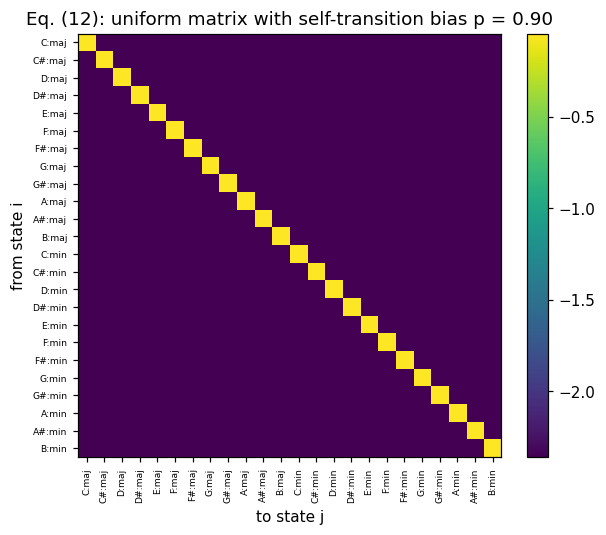

In [2]:
A = hmm.uniform_transition_matrix(p_self=0.90)
print("rows sum to one:", np.allclose(A.sum(axis=1), 1), " diagonal:", A[0, 0], " off-diagonal:", round(A[0, 1], 5))
fig, ax = plt.subplots(figsize=(6, 5))
plots.plot_matrix(A, ax=ax, title="Eq. (12): uniform matrix with self-transition bias p = 0.90", log=True)
plt.show()

## 6.3 Key invariance (Eq. 13)

The paper averages each 12×12 quality block along its *cyclic diagonals*,

$$ (M_{ti})_{i,j} = \frac{1}{12} \sum_{k=0}^{11} M_{(i+k) \bmod 12,\ (j+k) \bmod 12}, \qquad (13) $$

so that transition probabilities depend only on the **interval** between the chords, not on the key. On the uniform matrix of Eq. 12 this changes nothing — every cyclic diagonal is already constant. It becomes meaningful when the matrix is *estimated from data*, which the paper deliberately does not do ("to prevent overfitting"). We can do it as an experiment: the RWC-P chord annotations are on disk and contain about 20 000 chord segments.

self-transition probability learnt from 100 pop songs at a 100 ms grid: 0.945


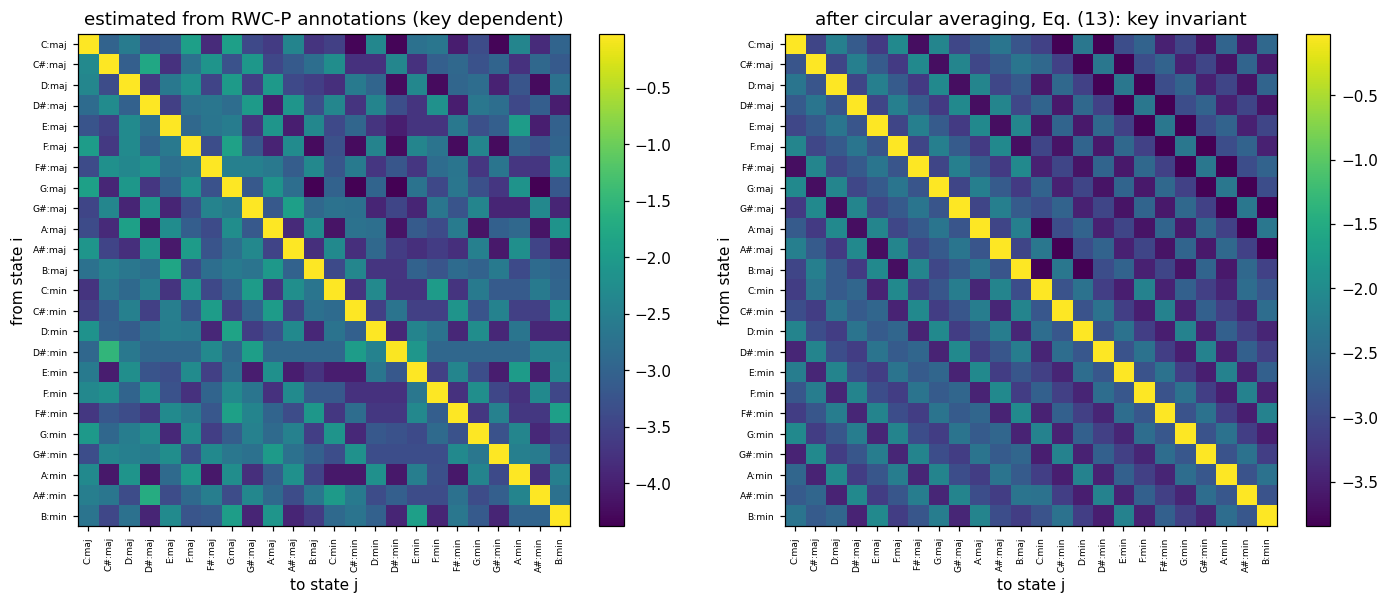

In [3]:
ann = data.ensure_annotations()
grid = 0.1     # seconds — the annotations' own temporal resolution
sequences = []
for rid in data.track_ids("P", ann):
    iv, lab = data.load_chords(rid, ann)
    t = np.arange(0.0, iv[-1, 1], grid) + grid / 2
    sequences.append(evaluate.labels_to_frames(iv, lab, t))
A_raw = hmm.estimate_transition_matrix(sequences, alpha=1.0, make_key_invariant=False)
A_ki = hmm.key_invariant(A_raw)
print("self-transition probability learnt from 100 pop songs at a 100 ms grid:", np.diag(A_ki).mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plots.plot_matrix(A_raw, ax=axes[0], title="estimated from RWC-P annotations (key dependent)", log=True)
plots.plot_matrix(A_ki, ax=axes[1], title="after circular averaging, Eq. (13): key invariant", log=True)
plt.tight_layout(); plt.show()

In [4]:
def roman(state, key_root=0):
    # Roman numeral of a major/minor triad relative to a major key (upper case = major)
    names = {0: "I", 1: "bII", 2: "II", 3: "bIII", 4: "III", 5: "IV", 6: "#IV", 7: "V", 8: "bVI", 9: "VI", 10: "bVII", 11: "VII"}
    n = names[(state % 12 - key_root) % 12]
    return n if state < 12 else n.lower()

row = A_ki[templates.label_to_index("C:maj")].copy()
row[templates.label_to_index("C:maj")] = 0           # look at *changes* only
top = np.argsort(row)[::-1][:6]
print("From C:maj (I), the most likely next chords in RWC-P are:")
for i in top:
    print(f"   {templates.CHORD_LABELS[i]:7s} {roman(i):5s} {row[i]:.4f}")

From C:maj (I), the most likely next chords in RWC-P are:
   F:maj   IV    0.0091
   G:maj   V     0.0077
   D:maj   II    0.0065
   D:min   ii    0.0047
   A#:maj  bVII  0.0043
   B:min   vii   0.0028


IV and V lead, as any songbook predicts; II (the secondary dominant of V) and ♭VII (the "mixolydian" chord of rock and pop) follow. Diagonal averaging turned a matrix full of song-specific idiosyncrasies into a statement about *intervals between chords*. This is the kind of music-theory prior Bello & Pickens (2005) built by hand; the paper cites them but keeps the uniform matrix. We will decode with both in notebooks 8–9.

## 6.4 Emissions (Eq. 15)

$$ b_c(x[t]) = \frac{\exp(r_c(x[t]))}{\sum_{c'=1}^{24} \exp(r_{c'}(x[t]))} \qquad (15) $$

The cosine similarities of notebook 5 are pushed through a softmax so that each frame yields a probability distribution over the 24 states. Here is a detail with large consequences: cosine similarities of non-negative chroma lie in $[0, 1]$, so $\exp(r)$ lies in $[1, e]$ — the resulting distributions are **almost flat**.

In [5]:
sr = features.SR
y, gt_intervals, gt_labels = synth.render_progression(synth.DEMO_PROGRESSION, 4.0, sr, timbre="piano")
chroma, times = features.cqt_chroma(y, sr)
truth = evaluate.labels_to_frames(gt_intervals, gt_labels, times)
sim = templates.cosine_similarity(chroma)

for tau in (1.0, 0.3, 0.1):
    B = hmm.softmax_emissions(sim, temperature=tau)
    print(f"temperature τ = {tau:<4}: best-state probability per frame ≈ {B.max(axis=0).mean():.3f}, "
          f"worst ≈ {B.min(axis=0).mean():.4f}, ratio best/worst ≈ {np.mean(B.max(axis=0) / B.min(axis=0)):.1f}")

temperature τ = 1.0 : best-state probability per frame ≈ 0.058, worst ≈ 0.0324, ratio best/worst ≈ 1.8
temperature τ = 0.3 : best-state probability per frame ≈ 0.117, worst ≈ 0.0164, ratio best/worst ≈ 7.2
temperature τ = 0.1 : best-state probability per frame ≈ 0.415, worst ≈ 0.0014, ratio best/worst ≈ 395.2


With τ = 1 (the paper's setting) the best state is barely twice as likely as the worst one. Compare that with the price of a chord change in the transition matrix:

$$ \ln p - \ln\frac{1-p}{23} = \ln 0.9 - \ln 0.00435 \approx 5.3 \text{ nats}. $$

Evidence is the difference between two states' log-emissions, i.e. the difference of their cosine similarities divided by τ. Between chords that have *no* note in common that gap can approach 1 nat per frame, so such a change is accepted within a few frames. Between chords that **share two of their three notes** — C:maj and A:min, F:maj and A:min — the gap is only about 0.1 nats per frame at τ = 1, so tens of frames (several seconds) of evidence are needed before visiting the second chord pays for the extra change. That is the smoothing the paper wants on noisy recordings, and also the **over-smoothing** it reports on RWC-P (§IV-B). `temperature` in `chordlab.hmm.softmax_emissions` lets you trade the two off; the paper corresponds to `temperature=1.0`.

## 6.5 Viterbi in the log domain (Eqs. 14, 16–18)

Multiplying thousands of probabilities underflows double precision — the paper explains this and switches to sums of logarithms. First the problem, in one line:

In [6]:
probs = np.full(2000, 1 / 24)
print("product of 2000 probabilities of 1/24:", np.prod(probs), "   (underflow: the true value is 24^-2000)")
print("sum of their logs:", np.sum(np.log(probs)).round(1), "   (perfectly representable)")

product of 2000 probabilities of 1/24: 0.0    (underflow: the true value is 24^-2000)
sum of their logs: -6356.1    (perfectly representable)


The recurrence the paper writes,

$$ D_\log(c, t) = \ln\!\big(b_c(x[t]) + \epsilon\big) + \max_j \big[ D_\log(j, t-1) + \ln(a_{jc} + \epsilon) \big], \qquad (14) $$

with back-pointers $E$ (Eq. 16), terminal state $s^*_N = \arg\max_i D_\log(i, N)$ (Eq. 17) and back-tracking $s^*_t = E(s^*_{t+1}, t+1)$ (Eq. 18), is `hmm.viterbi_log`. Read the source — it is twenty lines — and then run the whole decoder on the toy progression.

In [7]:
import inspect
print(inspect.getsource(hmm.viterbi_log))

def viterbi_log(B: np.ndarray, A: np.ndarray, pi: np.ndarray | None = None,
                eps: float = EPS) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Most probable state path for emission probabilities ``B[S, T]`` and transitions ``A[S, S]``.

    Implements Eqs. (14)–(18) with logarithms instead of products to avoid underflow:

        D_log(c, t) = ln(b_c(x[t]) + ε) + max_j [ D_log(j, t−1) + ln(a_jc + ε) ]      (14)
        E(c, t)     = argmax_j [ … ]                                                    (16)
        s*_T        = argmax_c D_log(c, T)                                              (17)
        s*_t        = E(s*_{t+1}, t+1)                                                  (18)

    Returns ``(path[T], D_log[S, T], E[S, T])``. ``E[c, t]`` stores the best predecessor of
    state ``c`` at frame ``t`` (the paper writes this as E(i, t−1)).
    """
    B = np.asarray(B, dtype=np.float64)
    S, T = B.shape
    if A.shape != (S, S):
        raise ValueError("trans

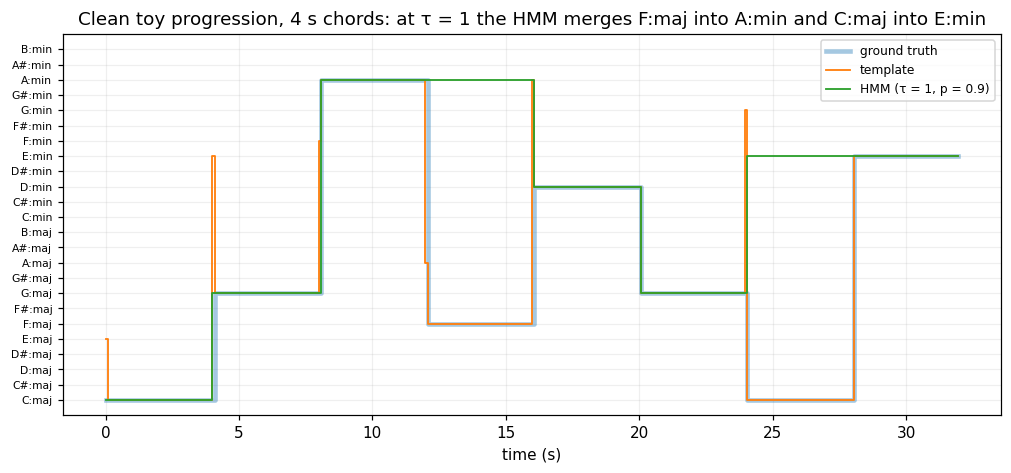

,TP,FP,FN,P,R,F1
template,339.0,6.0,6.0,0.9826,0.9826,0.9826
HMM (paper settings),258.0,87.0,87.0,0.7478,0.7478,0.7478


In [8]:
states_t, _ = templates.template_decode(chroma)
states_h, info = hmm.hmm_decode(chroma, p_self=0.90, temperature=1.0)        # the paper's settings

fig, ax = plt.subplots(figsize=(11, 4.5))
plots.plot_states(times, truth, states_t, states_h, labels=["ground truth", "template", "HMM (τ = 1, p = 0.9)"], ax=ax,
                  title="Clean toy progression, 4 s chords: at τ = 1 the HMM merges F:maj into A:min and C:maj into E:min")
plt.show()
pd.DataFrame({"template": evaluate.frame_prf(states_t, truth), "HMM (paper settings)": evaluate.frame_prf(states_h, truth)}).T[["TP", "FP", "FN", "P", "R", "F1"]].round(4)

Look closely: the HMM accepts the changes C→G, G→A:min and A:min→D:min almost instantly, but it never visits F:maj (12–16 s) and replaces C:maj (24–28 s) by E:min. The arithmetic of the previous section, on the actual similarities:

In [9]:
F, Am = templates.label_to_index("F:maj"), templates.label_to_index("A:min")
on_F = truth == F
gap = (sim[F, on_F] - sim[Am, on_F])              # log-emission gap per frame at τ = 1
switch_cost = np.log(0.9) - np.log(0.1 / 23)
print(f"during the F:maj chord ({on_F.sum()} frames): similarity gap F:maj − A:min = {gap.mean():.3f} nats per frame, "
      f"{gap.sum():.2f} nats in total")
print(f"one extra chord change costs ln(0.9) − ln(0.1/23) = {switch_cost:.2f} nats")
print("=> going A:min → F:maj → D:min instead of A:min → D:min does not pay; Viterbi skips F:maj." if gap.sum() < switch_cost else "=> visiting F:maj pays.")

during the F:maj chord (43 frames): similarity gap F:maj − A:min = 0.108 nats per frame, 4.64 nats in total
one extra chord change costs ln(0.9) − ln(0.1/23) = 5.33 nats
=> going A:min → F:maj → D:min instead of A:min → D:min does not pay; Viterbi skips F:maj.


On *clean* audio the template matcher wins: there is nothing to smooth, and the HMM pays for its prior by absorbing chords into similar neighbours. The picture flips when the frames are noisy — which is the situation the paper is really about. Let us sweep the two knobs on the toy band with drums and melody.

In [10]:
y_band = synth.add_melody(synth.add_drums(y, sr, level=1.0), gt_intervals, gt_labels, sr)
chroma_b, _ = features.cqt_chroma(y_band, sr)
states_tb, _ = templates.template_decode(chroma_b)
f1_template = evaluate.frame_prf(states_tb, truth)["F1"]

taus = [1.0, 0.5, 0.2, 0.1, 0.05]
ps = [0.5, 0.8, 0.9, 0.95, 0.99]
grid_f1 = pd.DataFrame(index=[f"τ = {t}" for t in taus], columns=[f"p = {p}" for p in ps], dtype=float)
for tau in taus:
    for p in ps:
        s, _ = hmm.hmm_decode(chroma_b, p_self=p, temperature=tau)
        grid_f1.loc[f"τ = {tau}", f"p = {p}"] = evaluate.frame_prf(s, truth)["F1"]
print(f"template matching on the noisy band: F1 = {f1_template:.3f}")
grid_f1.round(3).style.background_gradient(cmap="RdYlGn", vmin=0.3, vmax=1.0)

template matching on the noisy band: F1 = 0.574


,p = 0.5,p = 0.8,p = 0.9,p = 0.95,p = 0.99
τ = 1.0,0.501000,0.501000,0.501000,0.501000,0.252000
τ = 0.5,0.501000,0.501000,0.501000,0.501000,0.501000
τ = 0.2,0.594000,0.533000,0.594000,0.501000,0.501000
τ = 0.1,0.623000,0.623000,0.623000,0.623000,0.533000
τ = 0.05,0.687000,0.655000,0.623000,0.623000,0.623000


Two lessons hide in this table:

* **Smoothing helps when there is noise to smooth** — with sharper emissions (small τ) the HMM beats the template matcher clearly.
* **At the paper's τ = 1, the emissions are so flat that the prior does most of the talking.** Whether that helps or hurts depends on how long successive chords last and how *different* they are — which is why the paper finds a gain on RWC-R (slow children's songs with plain I–IV–V harmony) and losses on the fast-changing tracks of RWC-P (Table II).

## 6.6 Cross-check against librosa

`librosa.sequence.viterbi` implements the same algorithm. If our twenty lines are right, the paths must agree frame for frame.

In [11]:
B = info["emissions"]
ref = librosa.sequence.viterbi(B, info["transition"], p_init=np.full(24, 1 / 24))
print("frames where chordlab and librosa agree:", np.mean(ref == states_h) * 100, "%")

frames where chordlab and librosa agree: 100.0 %


## Exercises

1. Add a 25th state `N` with a flat template (all ones) and see whether precision improves on frames of silence (the paper notes that the 24-state model is "strictly penalised" there).
2. Decode the noisy band with `A_ki`, the matrix estimated from RWC-P, instead of the uniform one. Is a pop-music prior useful for a children's-song progression?
3. The paper's future work mentions *higher-order* Markov models. Explain in one paragraph why a first-order model cannot prefer II → V → I over II → I → V, and sketch how the state space would grow for a second-order model.